In [1]:
# plot recent US fires
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import linregress

# font required by PUP:
plt.rcParams['font.family'] = 'Myriad Pro'

# Import the csv datasets:
# -----------------------
dataset = pd.read_csv('../../../Data-for-teaching-staff/Forest-fires/US-fires/Wildfires-and-Acres.txt'\
                      ,sep='\t',na_values='NaN',comment='#',skipinitialspace=True,skip_blank_lines=True,header=None)
data = np.asarray(dataset.iloc[:, :].values)
#print(data)
#header = dataset.iloc[:, :].columns
fire_years=np.asarray(data[:,0])
fire_number=np.asarray(data[:,1])
# convert area to km^2:
acre_to_km2=0.00404686
fire_area=np.asarray(data[:,2])*acre_to_km2

print("done.")

done.


In [2]:
# Fit a regression line to the different time series:
# -----------------------------------------------------

x=1.0*fire_years; y=1.0*fire_area;
fit_area=linregress(x, y)
slope=fit_area.slope;
intercept=fit_area.intercept;
fire_area_fit=slope*fire_years+intercept
p=np.maximum(0.001,fit_area.pvalue);
r2=(fit_area.rvalue)**2
# show regression results in a box over the plots:
textstr_area = '\n'.join((
    r'$p<%.3f$' % (p, ),
    r'$r^2=%.2f$' % (r2, )))

x=1.0*fire_years; y=1.0*fire_number;
fit_number=linregress(x, y)
slope=fit_number.slope;
intercept=fit_number.intercept;
fire_number_fit=slope*fire_years+intercept
p=np.maximum(0.001,fit_number.pvalue);
r2=(fit_number.rvalue)**2
# show regression results in a box over the plots:
textstr_number = '\n'.join((
    r'$p<%.3f$' % (p, ),
    r'$r^2=%.2f$' % (r2, )))

print("done.")

done.


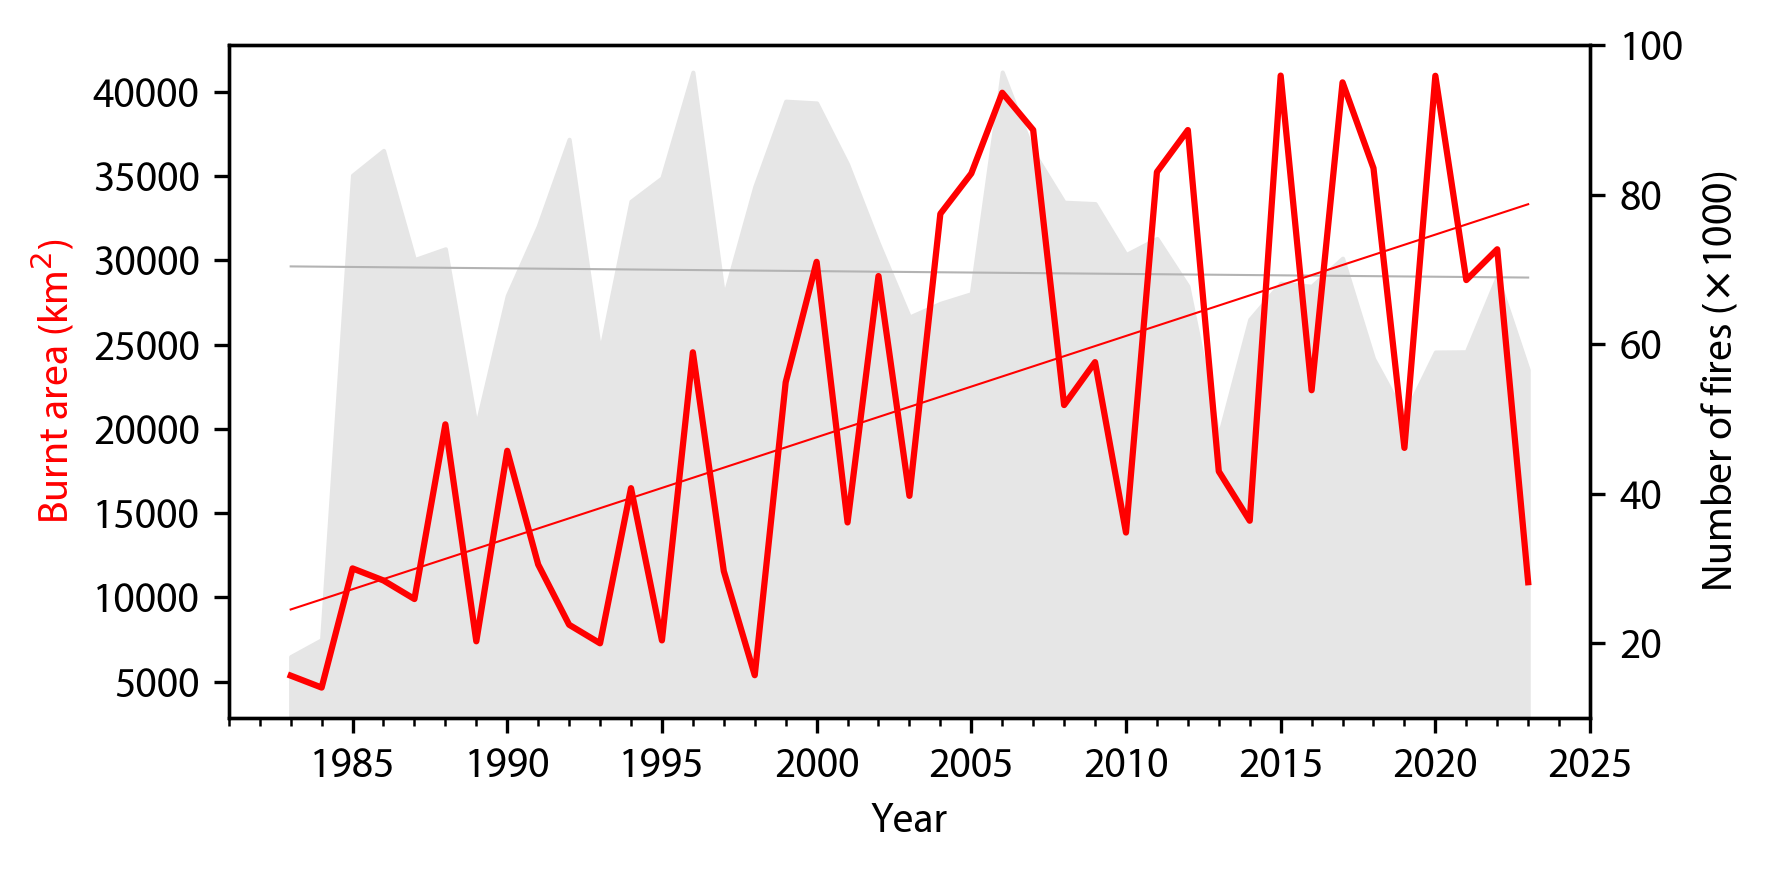

In [3]:
# plot
grey=[0.9,0.9,0.9]
darkgrey=[0.7,0.7,0.7]
fig=plt.figure(figsize=(6,3),dpi=300)

ax1=plt.gca()
ax1.plot(fire_years,fire_area,'r')
ax1.plot(fire_years,fire_area_fit,lw=0.5,color='r')
ax1.set_xlabel("Year")
ax1.set_xticks(np.arange(1980,2030,1), minor=True)
#ax1.set_xlim(1982,2021)
ax1.set_ylabel("Burnt area (km$^2$)",color="r")

ax2 = ax1.twinx()
y1=fire_number/1000
y2=0
ax2.fill_between(fire_years,y1,y2,color=grey)
ax2.plot(fire_years,fire_number_fit/1000,lw=0.5,color=darkgrey)
ax2.set_ylabel("Number of fires ($\\times$1000)",color='k')
ax2.set_ylim(10,100)
ax1.set_zorder(10)
ax1.patch.set_visible(False)
ax2.set_zorder(0)


plt.tight_layout()
plt.show()
fig.savefig("Output/forest-fires-global-timeseries.pdf")

In [4]:
np.save("Output/to-pickle/US_fire_years.npy",fire_years)
np.save("Output/to-pickle/US_fire_area.npy",fire_area)
np.save("Output/to-pickle/US_fire_number.npy",fire_number)
print("done.")

done.
